In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load the NSW Fire History shapefile
fire_history = gpd.read_file('/Users/josephpradil/Desktop/project1_bushfire/fire_npwsfirehistory (1)/NPWSFireHistory.shp')

# Basic info
print("Shape:", fire_history.shape)
print("\nColumns:", fire_history.columns.tolist())
print("\nCRS:", fire_history.crs)
print("\nFirst 5 rows:")
print(fire_history.head())

Shape: (37588, 9)

Columns: ['FireName', 'FireNo', 'Label', 'StartDate', 'EndDate', 'AreaHa', 'PerimeterM', 'VerDate', 'geometry']

CRS: EPSG:4283

First 5 rows:
  FireName  FireNo                    Label  StartDate EndDate      AreaHa  \
0      NaN     NaN  1970-71 Prescribed Burn        NaT     NaT  299.985464   
1      NaN  70/161  1970-71 Prescribed Burn        NaT     NaT  309.025645   
2      NaN     NaN  1970-71 Prescribed Burn 1970-07-01     NaT   13.600002   
3      NaN       0  1971-72 Prescribed Burn 1971-07-01     NaT   58.994371   
4      NaN       0  1971-72 Prescribed Burn 1971-07-01     NaT  383.155154   

     PerimeterM   VerDate                                           geometry  
0   8615.637120  7/5/2026  POLYGON ((152.77796 -31.63806, 152.77822 -31.6...  
1  20657.633993  7/5/2026  POLYGON ((151.50894 -31.98245, 151.50911 -31.9...  
2   1999.487701  7/5/2026  POLYGON ((153.14728 -30.17573, 153.14721 -30.1...  
3   5312.210152  7/5/2026  POLYGON ((152.2127 -32.241

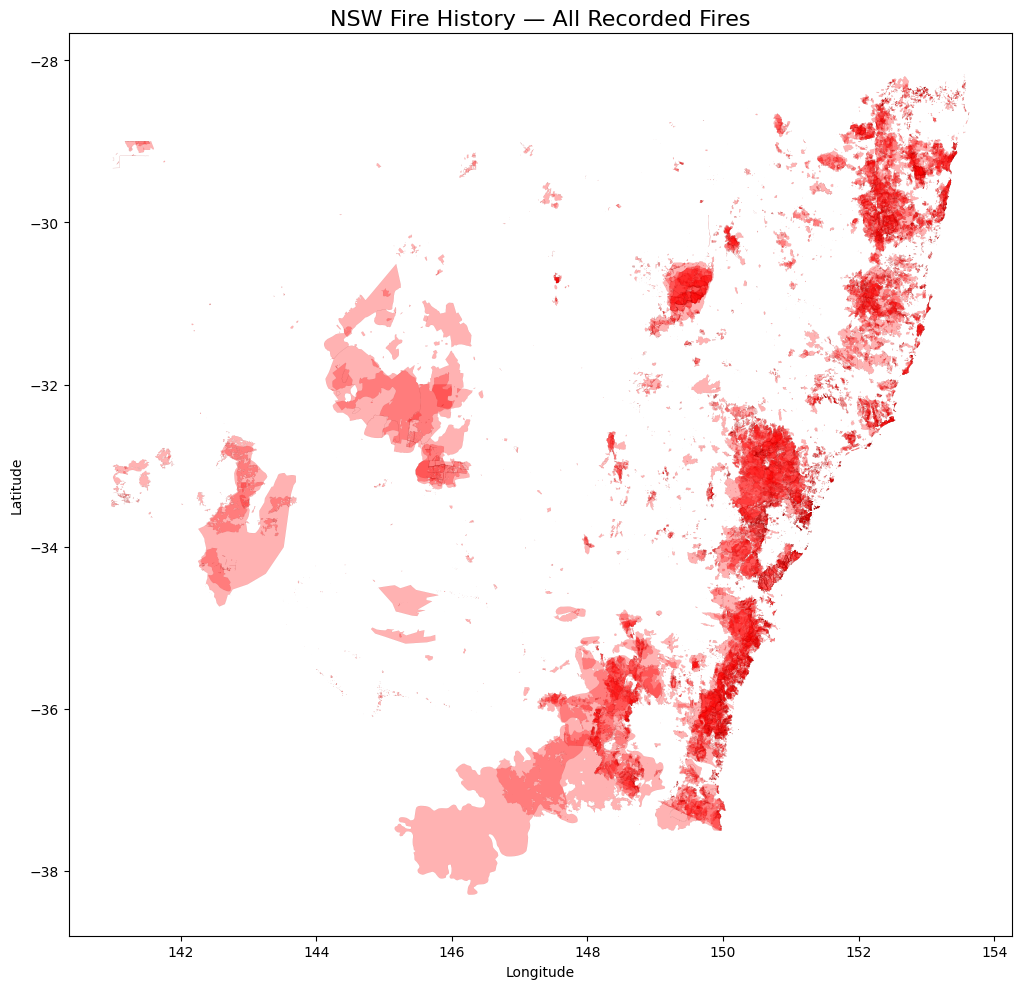

Total fires recorded: 37,588
Total area burned: 34,446,191 hectares


In [2]:
# Plot all fire history
fig, ax = plt.subplots(figsize=(12, 10))

fire_history.plot(ax=ax, 
                  color='red', 
                  alpha=0.3, 
                  edgecolor='darkred',
                  linewidth=0.1)

ax.set_title('NSW Fire History — All Recorded Fires', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('nsw_fire_history.png', dpi=150)
plt.show()

print(f"Total fires recorded: {len(fire_history):,}")
print(f"Total area burned: {fire_history['AreaHa'].sum():,.0f} hectares")

In [3]:
import folium
import json

# Convert to WGS84 for folium
fire_wgs84 = fire_history.to_crs(epsg=4326)

# Create folium map centered on NSW
m = folium.Map(location=[-32.5, 147.5], zoom_start=6)

# Add fire history as a layer (use recent fires only to keep it fast)
recent_fires = fire_wgs84[fire_wgs84['StartDate'] >= '2000-01-01'].copy()

print(f"Fires since 2000: {len(recent_fires):,}")
print("Adding to map...")

# Add to map
folium.GeoJson(
    recent_fires,
    style_function=lambda x: {
        'fillColor': 'red',
        'color': 'darkred',
        'weight': 0.5,
        'fillOpacity': 0.4
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['Label', 'StartDate', 'AreaHa'],
        aliases=['Fire Name', 'Start Date', 'Area (Ha)']
    )
).add_to(m)

m.save('/Users/josephpradil/Desktop/gis-portfolio/nsw_fire_history.html')
print("Interactive map saved!")

Fires since 2000: 17,630
Adding to map...


TypeError: Object of type Timestamp is not JSON serializable

In [4]:
# Convert dates to strings to fix JSON serialization
recent_fires['StartDate'] = recent_fires['StartDate'].astype(str)
recent_fires['EndDate'] = recent_fires['EndDate'].astype(str)

# Create folium map centered on NSW
m = folium.Map(location=[-32.5, 147.5], zoom_start=6)

# Add to map
folium.GeoJson(
    recent_fires,
    style_function=lambda x: {
        'fillColor': 'red',
        'color': 'darkred',
        'weight': 0.5,
        'fillOpacity': 0.4
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['Label', 'StartDate', 'AreaHa'],
        aliases=['Fire Name', 'Start Date', 'Area (Ha)']
    )
).add_to(m)

m.save('/Users/josephpradil/Desktop/gis-portfolio/nsw_fire_history.html')
print("Interactive map saved!")

Interactive map saved!


In [5]:
# Simplify geometries to reduce file size
recent_fires_simple = recent_fires.copy()
recent_fires_simple['geometry'] = recent_fires_simple.geometry.simplify(0.001)

# Create map
m = folium.Map(location=[-32.5, 147.5], zoom_start=6)

recent_fires_simple['StartDate'] = recent_fires_simple['StartDate'].astype(str)
recent_fires_simple['EndDate'] = recent_fires_simple['EndDate'].astype(str)

folium.GeoJson(
    recent_fires_simple,
    style_function=lambda x: {
        'fillColor': 'red',
        'color': 'darkred',
        'weight': 0.5,
        'fillOpacity': 0.4
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['Label', 'StartDate', 'AreaHa'],
        aliases=['Fire Name', 'Start Date', 'Area (Ha)']
    )
).add_to(m)

m.save('/Users/josephpradil/Desktop/gis-portfolio/nsw_fire_history.html')
print("Simplified map saved!")

Simplified map saved!


In [6]:
# Only keep large fires over 1000 hectares
large_fires = recent_fires[recent_fires['AreaHa'] > 1000].copy()
large_fires['geometry'] = large_fires.geometry.simplify(0.001)
large_fires['StartDate'] = large_fires['StartDate'].astype(str)
large_fires['EndDate'] = large_fires['EndDate'].astype(str)

print(f"Large fires (>1000ha): {len(large_fires):,}")

# Create map
m = folium.Map(location=[-32.5, 147.5], zoom_start=6)

folium.GeoJson(
    large_fires,
    style_function=lambda x: {
        'fillColor': 'red',
        'color': 'darkred',
        'weight': 0.5,
        'fillOpacity': 0.4
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['Label', 'StartDate', 'AreaHa'],
        aliases=['Fire Name', 'Start Date', 'Area (Ha)']
    )
).add_to(m)

m.save('/Users/josephpradil/Desktop/gis-portfolio/nsw_fire_history.html')
print("Map saved!")

Large fires (>1000ha): 1,161
Map saved!


In [7]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Reload the fire data
fire_history = gpd.read_file('/Users/josephpradil/Desktop/project1_bushfire/fire_npwsfirehistory (1)/NPWSFireHistory.shp')

# Convert to projected CRS for accurate area/distance calcs (GDA94 / NSW Lambert)
fire_projected = fire_history.to_crs(epsg=3308)

print("Data loaded:", fire_projected.shape)
print("Date range:", fire_history['StartDate'].min(), "to", fire_history['StartDate'].max())

Data loaded: (37588, 9)
Date range: 1899-12-30 00:00:00 to 2026-04-25 00:00:00


In [8]:
import numpy as np
from shapely.geometry import box

# Get the bounds of all fire data (in projected coordinates, metres)
minx, miny, maxx, maxy = fire_projected.total_bounds

# Create a grid of 10km x 10km cells
cell_size = 10000  # 10km in metres

grid_cells = []
x = minx
while x < maxx:
    y = miny
    while y < maxy:
        grid_cells.append(box(x, y, x + cell_size, y + cell_size))
        y += cell_size
    x += cell_size

# Build a GeoDataFrame from the grid
grid = gpd.GeoDataFrame({'geometry': grid_cells}, crs=fire_projected.crs)
grid['cell_id'] = range(len(grid))

print(f"Grid created: {len(grid):,} cells of 10km x 10km")

Grid created: 13,764 cells of 10km x 10km


In [9]:
# Spatial join: match each fire to the grid cells it overlaps
joined = gpd.sjoin(grid, fire_projected, how='left', predicate='intersects')

# Count how many fires hit each cell
fire_counts = joined.groupby('cell_id').size().reset_index(name='fire_count')

# Cells with no fires will have counted themselves, fix that
# (cells with no match get NaN in the join, so count = 1 falsely)
no_fire = joined[joined['index_right'].isna()]['cell_id'].unique()
fire_counts.loc[fire_counts['cell_id'].isin(no_fire), 'fire_count'] = 0

# Merge counts back to the grid
grid = grid.merge(fire_counts, on='cell_id', how='left')
grid['fire_count'] = grid['fire_count'].fillna(0)

print("Fire count per cell calculated!")
print(grid['fire_count'].describe())

Fire count per cell calculated!
count    13764.000000
mean         3.995495
std         16.560673
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        450.000000
Name: fire_count, dtype: float64


In [10]:
# Create risk categories based on fire count
def risk_category(count):
    if count == 0:
        return 'No recorded fires'
    elif count <= 5:
        return 'Low'
    elif count <= 20:
        return 'Medium'
    elif count <= 50:
        return 'High'
    else:
        return 'Extreme'

grid['risk_level'] = grid['fire_count'].apply(risk_category)

# See how many cells fall into each category
print(grid['risk_level'].value_counts())

risk_level
No recorded fires    10013
Low                   2166
Medium                 789
High                   552
Extreme                244
Name: count, dtype: int64


/var/folders/nc/kql9kdyn21g70cyyl5qh4_400000gn/T/ipykernel_74734/3380754103.py:22: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title='Risk Level')
/var/folders/nc/kql9kdyn21g70cyyl5qh4_400000gn/T/ipykernel_74734/3380754103.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Risk Level')


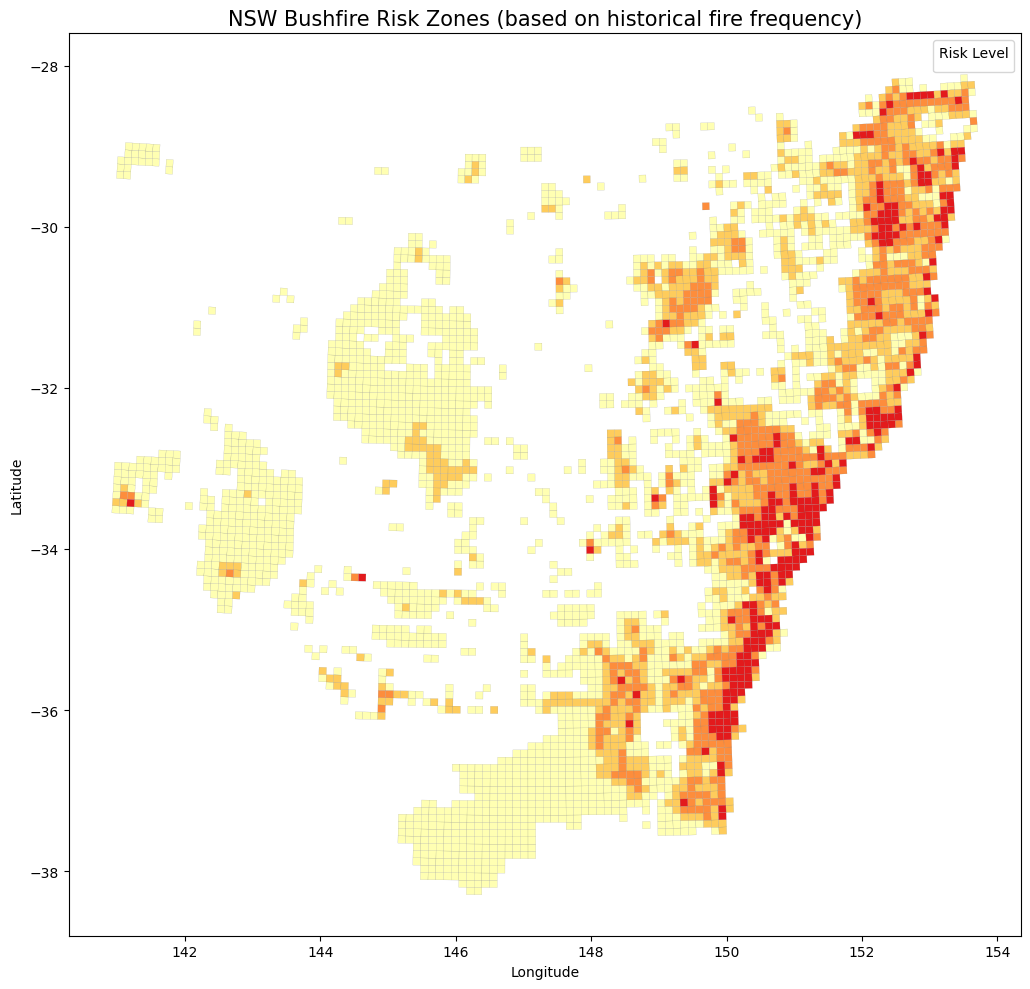

Risk zone preview created!


In [11]:
# Keep only cells that have burned at least once
risk_grid = grid[grid['fire_count'] > 0].copy()

# Convert back to WGS84 for folium mapping
risk_grid_wgs = risk_grid.to_crs(epsg=4326)

# Quick static preview with matplotlib
fig, ax = plt.subplots(figsize=(12, 10))

color_map = {
    'Low': '#ffffb2',
    'Medium': '#fecc5c',
    'High': '#fd8d3c',
    'Extreme': '#e31a1c'
}

for level, color in color_map.items():
    subset = risk_grid_wgs[risk_grid_wgs['risk_level'] == level]
    subset.plot(ax=ax, color=color, edgecolor='grey', linewidth=0.1, label=level)

ax.set_title('NSW Bushfire Risk Zones (based on historical fire frequency)', fontsize=15)
ax.legend(title='Risk Level')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('/Users/josephpradil/Desktop/gis-portfolio/nsw_risk_zones.png', dpi=150)
plt.show()

print("Risk zone preview created!")

In [12]:
import folium

# Center on NSW
m = folium.Map(location=[-32.5, 147.5], zoom_start=6, tiles='CartoDB positron')

color_map = {
    'Low': '#ffffb2',
    'Medium': '#fecc5c',
    'High': '#fd8d3c',
    'Extreme': '#e31a1c'
}

# Convert dates aren't needed here since grid has no dates
folium.GeoJson(
    risk_grid_wgs,
    style_function=lambda feature: {
        'fillColor': color_map.get(feature['properties']['risk_level'], 'grey'),
        'color': 'grey',
        'weight': 0.2,
        'fillOpacity': 0.7
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['risk_level', 'fire_count'],
        aliases=['Risk Level:', 'Times Burned:']
    )
).add_to(m)

# Add a legend
legend_html = '''
<div style="position: fixed; bottom: 40px; left: 40px; z-index: 1000;
     background: white; padding: 12px; border-radius: 6px; border: 2px solid grey;
     font-family: sans-serif; font-size: 13px;">
     <b>Bushfire Risk Level</b><br>
     <i style="background:#ffffb2;width:12px;height:12px;display:inline-block;border:1px solid grey"></i> Low (1-5 fires)<br>
     <i style="background:#fecc5c;width:12px;height:12px;display:inline-block;border:1px solid grey"></i> Medium (6-20)<br>
     <i style="background:#fd8d3c;width:12px;height:12px;display:inline-block;border:1px solid grey"></i> High (21-50)<br>
     <i style="background:#e31a1c;width:12px;height:12px;display:inline-block;border:1px solid grey"></i> Extreme (50+)<br>
     <small>Based on NSW fire history 1900-2026</small>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

m.save('/Users/josephpradil/Desktop/gis-portfolio/nsw_bushfire_risk.html')
print("Interactive risk map saved!")

Interactive risk map saved!


In [13]:
print(risk_grid_wgs.shape)
print(risk_grid_wgs['risk_level'].value_counts())

(3751, 4)
risk_level
Low        2166
Medium      789
High        552
Extreme     244
Name: count, dtype: int64


In [14]:
# Load the Kontur population data for Australia
pop = gpd.read_file('/Users/josephpradil/Desktop/project1_bushfire/kontur_population_AU_20231101.gpkg')

print("Population hexagons loaded:", pop.shape)
print("\nColumns:", pop.columns.tolist())
print("\nCRS:", pop.crs)
print("\nFirst few rows:")
print(pop.head())

Population hexagons loaded: (517689, 3)

Columns: ['h3', 'population', 'geometry']

CRS: EPSG:3857

First few rows:
                h3  population  \
0  88e0b6b1b5fffff         1.0   
1  88e0b6b1b1fffff         3.0   
2  88da7335dbfffff         1.0   
3  88da733585fffff         1.0   
4  88da7334e7fffff         1.0   

                                            geometry  
0  POLYGON ((8171665.121 -6986645.812, 8171843.06...  
1  POLYGON ((8170633.183 -6987879.168, 8170811.28...  
2  POLYGON ((17681976.59 -7317751.61, 17682021.27...  
3  POLYGON ((17684770.887 -7311118.564, 17684815....  
4  POLYGON ((17681089.131 -7319071.513, 17681133....  


In [15]:
# Reproject population hexagons to match the risk grid CRS (NSW Lambert)
pop_nsw = pop.to_crs(epsg=3308)

# Use the centroid of each hexagon as its point location (faster, cleaner join)
pop_points = pop_nsw.copy()
pop_points['geometry'] = pop_points.geometry.centroid

# Spatial join: assign each population hexagon to the risk cell it falls in
# (risk_grid is the projected grid with fire_count + risk_level)
pop_in_cells = gpd.sjoin(pop_points, risk_grid, how='inner', predicate='within')

# Sum population per risk cell
pop_per_cell = pop_in_cells.groupby('cell_id')['population'].sum().reset_index()
pop_per_cell.columns = ['cell_id', 'total_population']

# Merge population back into the risk grid
risk_grid = risk_grid.merge(pop_per_cell, on='cell_id', how='left')
risk_grid['total_population'] = risk_grid['total_population'].fillna(0)

print("Population overlaid onto risk grid!")
print(f"Total population in fire-affected cells: {risk_grid['total_population'].sum():,.0f}")
print("\nPopulation by risk level:")
print(risk_grid.groupby('risk_level')['total_population'].sum().sort_values(ascending=False))

Population overlaid onto risk grid!
Total population in fire-affected cells: 8,143,798

Population by risk level:
risk_level
Extreme    2621282.0
Low        2296758.0
Medium     1841029.0
High       1384729.0
Name: total_population, dtype: float64


In [16]:
# Calculate a consequence score: weight risk level by population
risk_weights = {'Low': 1, 'Medium': 2, 'High': 3, 'Extreme': 4}
risk_grid['risk_weight'] = risk_grid['risk_level'].map(risk_weights)

# Consequence score = risk weight × population
risk_grid['consequence_score'] = risk_grid['risk_weight'] * risk_grid['total_population']

# Top 10 highest-consequence cells
top_cells = risk_grid.nlargest(10, 'consequence_score')
print("Top 10 highest-consequence fire zones (risk × population):")
print(top_cells[['cell_id', 'fire_count', 'risk_level', 'total_population', 'consequence_score']].to_string(index=False))

Top 10 highest-consequence fire zones (risk × population):
 cell_id  fire_count risk_level  total_population  consequence_score
   10815          56    Extreme          472405.0          1889620.0
   10592          70    Extreme          234733.0           938932.0
   10705         225    Extreme          228913.0           915652.0
   10816         162    Extreme          205953.0           823812.0
   10703           7     Medium          380576.0           761152.0
   10814          44       High          247828.0           743484.0
   10482          23       High          235957.0           707871.0
   11380          77    Extreme          160878.0           643512.0
   10594          17     Medium          290157.0           580314.0
   10702         112    Extreme          136184.0           544736.0


In [17]:
import folium

# Reproject the full risk grid (now with population) to WGS84 for mapping
risk_grid_wgs = risk_grid.to_crs(epsg=4326)

# Only show cells that have population AND fire history
consequence_cells = risk_grid_wgs[risk_grid_wgs['total_population'] > 0].copy()

# Color by consequence score using quantile breaks
import numpy as np
breaks = consequence_cells['consequence_score'].quantile([0, 0.5, 0.75, 0.9, 0.99]).values

def consequence_color(score):
    if score >= breaks[4]:
        return '#800026'   # very high
    elif score >= breaks[3]:
        return '#e31a1c'
    elif score >= breaks[2]:
        return '#fd8d3c'
    elif score >= breaks[1]:
        return '#fecc5c'
    else:
        return '#ffffb2'

m = folium.Map(location=[-33.8, 150.5], zoom_start=8, tiles='CartoDB positron')

folium.GeoJson(
    consequence_cells,
    style_function=lambda f: {
        'fillColor': consequence_color(f['properties']['consequence_score']),
        'color': 'grey', 'weight': 0.2, 'fillOpacity': 0.7
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['risk_level', 'fire_count', 'total_population', 'consequence_score'],
        aliases=['Fire Risk:', 'Times Burned:', 'Population:', 'Consequence Score:']
    )
).add_to(m)

legend_html = '''
<div style="position: fixed; bottom: 40px; left: 40px; z-index: 1000;
     background: white; padding: 12px; border-radius: 6px; border: 2px solid grey;
     font-family: sans-serif; font-size: 13px;">
     <b>Bushfire Consequence</b><br>
     <small>(fire risk &times; population exposed)</small><br>
     <i style="background:#800026;width:12px;height:12px;display:inline-block"></i> Very High<br>
     <i style="background:#e31a1c;width:12px;height:12px;display:inline-block"></i> High<br>
     <i style="background:#fd8d3c;width:12px;height:12px;display:inline-block"></i> Moderate<br>
     <i style="background:#fecc5c;width:12px;height:12px;display:inline-block"></i> Low<br>
     <i style="background:#ffffb2;width:12px;height:12px;display:inline-block"></i> Minimal<br>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

m.save('/Users/josephpradil/Desktop/gis-portfolio/nsw_bushfire_consequence.html')
print("Consequence map saved!")

Consequence map saved!
